# Data Analysis

## Importing Libraries

In [119]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

## Importing of CSV file

In [120]:
df1= pd.read_csv(r"/Users/mac/Downloads/Dissertation Datasets/Delayed Discharge by NHS Health Board.csv")
df2= pd.read_excel(r"/Users/mac/Downloads/Dissertation Datasets/260131DatastoreExternal.xls")
df3= pd.read_excel(r"/Users/mac/Downloads/Dissertation Datasets/Mid-year population estimates by NHS health board, sex and single year of age, 1981-2024.xlsx")

### Data Preprocessing and Feature Engineering for NHS Delayed Discharge Dataset

In [121]:
df1

,_id,MonthOfDelay,HBT,HBTQF,AgeGroup,AgeGroupQF,ReasonForDelay,ReasonForDelayQF,NumberOfDelayedBedDays,AverageDailyNumberOfDelayedBeds
0,1,201607,S08000015,NaN,18plus,d,All Delay Reasons,d,2574,83
1,2,201607,S08000015,NaN,18plus,d,Health and Social Care Reasons,NaN,1976,64
2,3,201607,S08000015,NaN,18plus,d,Patient and Family Related Reasons,NaN,0,0
3,4,201607,S08000015,NaN,18plus,d,Code 9 AWI,NaN,472,15
4,5,201607,S08000015,NaN,18plus,d,Code 9 Non-AWI,NaN,126,4
...,...,...,...,...,...,...,...,...,...,...
25870,25871,202601,S92000003,d,75plus,NaN,All Delay Reasons,d,39876,1286
25871,25872,202601,S92000003,d,75plus,NaN,Health and Social Care Reasons,NaN,28788,929
25872,25873,202601,S92000003,d,75plus,NaN,Patient and Family Related Reasons,NaN,1412,46
25873,25874,202601,S92000003,d,75plus,NaN,Code 9 AWI,NaN,8761,283


#### Data Information

In [122]:
df1.head()

,_id,MonthOfDelay,HBT,HBTQF,AgeGroup,AgeGroupQF,ReasonForDelay,ReasonForDelayQF,NumberOfDelayedBedDays,AverageDailyNumberOfDelayedBeds
0,1,201607,S08000015,NaN,18plus,d,All Delay Reasons,d,2574,83
1,2,201607,S08000015,NaN,18plus,d,Health and Social Care Reasons,NaN,1976,64
2,3,201607,S08000015,NaN,18plus,d,Patient and Family Related Reasons,NaN,0,0
3,4,201607,S08000015,NaN,18plus,d,Code 9 AWI,NaN,472,15
4,5,201607,S08000015,NaN,18plus,d,Code 9 Non-AWI,NaN,126,4


In [123]:
df1.sample()

,_id,MonthOfDelay,HBT,HBTQF,AgeGroup,AgeGroupQF,ReasonForDelay,ReasonForDelayQF,NumberOfDelayedBedDays,AverageDailyNumberOfDelayedBeds
11055,11056,202008,S08000017,NaN,18plus,d,All Delay Reasons,d,799,26


In [124]:
df1.columns

Index(['_id', 'MonthOfDelay', 'HBT', 'HBTQF', 'AgeGroup', 'AgeGroupQF',
       'ReasonForDelay', 'ReasonForDelayQF', 'NumberOfDelayedBedDays',
       'AverageDailyNumberOfDelayedBeds'],
      dtype='str')

In [125]:
df1.shape

(25875, 10)

#### Data Cleaning and Transformation

In [126]:
df1

,_id,MonthOfDelay,HBT,HBTQF,AgeGroup,AgeGroupQF,ReasonForDelay,ReasonForDelayQF,NumberOfDelayedBedDays,AverageDailyNumberOfDelayedBeds
0,1,201607,S08000015,NaN,18plus,d,All Delay Reasons,d,2574,83
1,2,201607,S08000015,NaN,18plus,d,Health and Social Care Reasons,NaN,1976,64
2,3,201607,S08000015,NaN,18plus,d,Patient and Family Related Reasons,NaN,0,0
3,4,201607,S08000015,NaN,18plus,d,Code 9 AWI,NaN,472,15
4,5,201607,S08000015,NaN,18plus,d,Code 9 Non-AWI,NaN,126,4
...,...,...,...,...,...,...,...,...,...,...
25870,25871,202601,S92000003,d,75plus,NaN,All Delay Reasons,d,39876,1286
25871,25872,202601,S92000003,d,75plus,NaN,Health and Social Care Reasons,NaN,28788,929
25872,25873,202601,S92000003,d,75plus,NaN,Patient and Family Related Reasons,NaN,1412,46
25873,25874,202601,S92000003,d,75plus,NaN,Code 9 AWI,NaN,8761,283


In [127]:
#Checking for duplicates
duplicate_rows = df1.duplicated().sum()
duplicate_rows

0

In [128]:
#Checking for Null Values
df1.isnull().sum()

_id                                    0
MonthOfDelay                           0
HBT                                    0
HBTQF                              24150
AgeGroup                               0
AgeGroupQF                         17250
ReasonForDelay                         0
ReasonForDelayQF                   20700
NumberOfDelayedBedDays                 0
AverageDailyNumberOfDelayedBeds        0
dtype: int64

In [129]:
#Dropping Columns
drop_cols = ['_id','HBTQF', 'AgeGroupQF', 'ReasonForDelayQF','AverageDailyNumberOfDelayedBeds']
df1.drop(columns=drop_cols, errors='ignore', inplace=True)
df1

,MonthOfDelay,HBT,AgeGroup,ReasonForDelay,NumberOfDelayedBedDays
0,201607,S08000015,18plus,All Delay Reasons,2574
1,201607,S08000015,18plus,Health and Social Care Reasons,1976
2,201607,S08000015,18plus,Patient and Family Related Reasons,0
3,201607,S08000015,18plus,Code 9 AWI,472
4,201607,S08000015,18plus,Code 9 Non-AWI,126
...,...,...,...,...,...
25870,202601,S92000003,75plus,All Delay Reasons,39876
25871,202601,S92000003,75plus,Health and Social Care Reasons,28788
25872,202601,S92000003,75plus,Patient and Family Related Reasons,1412
25873,202601,S92000003,75plus,Code 9 AWI,8761


In [130]:
#Dropping Rows
df1 = df1.drop(df1[df1["AgeGroup"] == "18plus"].index)
df1 = df1.drop(df1[df1["ReasonForDelay"] == "All Delay Reasons"].index)

In [131]:
df1

,MonthOfDelay,HBT,AgeGroup,ReasonForDelay,NumberOfDelayedBedDays
6,201607,S08000015,18-74,Health and Social Care Reasons,222
7,201607,S08000015,18-74,Patient and Family Related Reasons,0
8,201607,S08000015,18-74,Code 9 AWI,124
9,201607,S08000015,18-74,Code 9 Non-AWI,9
11,201607,S08000015,75plus,Health and Social Care Reasons,1754
...,...,...,...,...,...
25869,202601,S92000003,18-74,Code 9 Non-AWI,3180
25871,202601,S92000003,75plus,Health and Social Care Reasons,28788
25872,202601,S92000003,75plus,Patient and Family Related Reasons,1412
25873,202601,S92000003,75plus,Code 9 AWI,8761


In [132]:
#datetime conversion
df1["MonthOfDelay"] = pd.to_datetime(df1["MonthOfDelay"].astype(str), format="%Y%m")

df1

,MonthOfDelay,HBT,AgeGroup,ReasonForDelay,NumberOfDelayedBedDays
6,2016-07-01,S08000015,18-74,Health and Social Care Reasons,222
7,2016-07-01,S08000015,18-74,Patient and Family Related Reasons,0
8,2016-07-01,S08000015,18-74,Code 9 AWI,124
9,2016-07-01,S08000015,18-74,Code 9 Non-AWI,9
11,2016-07-01,S08000015,75plus,Health and Social Care Reasons,1754
...,...,...,...,...,...
25869,2026-01-01,S92000003,18-74,Code 9 Non-AWI,3180
25871,2026-01-01,S92000003,75plus,Health and Social Care Reasons,28788
25872,2026-01-01,S92000003,75plus,Patient and Family Related Reasons,1412
25873,2026-01-01,S92000003,75plus,Code 9 AWI,8761


In [133]:
#ReasonsForDelay Column Conversion
df1 = df1.pivot_table(
    index=["HBT", "MonthOfDelay"],
    columns="ReasonForDelay",
    values="NumberOfDelayedBedDays",
    aggfunc="sum"
).reset_index()

df1

ReasonForDelay,HBT,MonthOfDelay,Code 9 AWI,Code 9 Non-AWI,Health and Social Care Reasons,Patient and Family Related Reasons
0,S08000015,2016-07-01,472,126,1976,0
1,S08000015,2016-08-01,450,224,2186,44
2,S08000015,2016-09-01,517,285,1745,27
3,S08000015,2016-10-01,641,209,1861,0
4,S08000015,2016-11-01,579,138,2435,0
...,...,...,...,...,...,...
1720,S92000003,2025-09-01,12394,4059,39919,2275
1721,S92000003,2025-10-01,12865,3329,42653,2563
1722,S92000003,2025-11-01,12487,3984,40501,2178
1723,S92000003,2025-12-01,12990,4257,41577,2142


In [134]:
#Rename Columns
df1.columns.name = None
df1 = df1.rename(columns={
    "Health and Social Care Reasons": "HealthSocial",
    "Patient and Family Related Reasons": "PatientFamily",
    "Code 9 AWI": "AWI",
    "Code 9 Non-AWI": "NonAWI"
})

In [135]:
df1["TotalDelayedBedDays"] = (
    df1["HealthSocial"] +
    df1["PatientFamily"] +
    df1["AWI"] +
    df1["NonAWI"]
)

In [136]:
#lag feature
df1["PrevMonthDelay"] = df1.groupby("HBT")["TotalDelayedBedDays"].shift(1)

In [137]:
#Splitting Month of delay Column
df1["Year"] = df1["MonthOfDelay"].dt.year
df1["Month"] = df1["MonthOfDelay"].dt.month
df1["Quarter"] = df1["MonthOfDelay"].dt.quarter

In [138]:
#Keeping specific years(2019-2024)
df1 = df1[df1["Year"].between(2019, 2024)]

In [139]:
df1

,HBT,MonthOfDelay,AWI,NonAWI,HealthSocial,PatientFamily,TotalDelayedBedDays,PrevMonthDelay,Year,Month,Quarter
30,S08000015,2019-01-01,462,85,3072,2,3621,3862.0,2019,1,1
31,S08000015,2019-02-01,375,128,3216,0,3719,3621.0,2019,2,1
32,S08000015,2019-03-01,470,109,2879,65,3523,3719.0,2019,3,1
33,S08000015,2019-04-01,317,33,3354,34,3738,3523.0,2019,4,2
34,S08000015,2019-05-01,434,55,3660,0,4149,3738.0,2019,5,2
...,...,...,...,...,...,...,...,...,...,...,...
1707,S92000003,2024-08-01,13015,3674,43567,1747,62003,61165.0,2024,8,3
1708,S92000003,2024-09-01,12379,4112,40651,1891,59033,62003.0,2024,9,3
1709,S92000003,2024-10-01,12870,3894,44379,1771,62914,59033.0,2024,10,4
1710,S92000003,2024-11-01,12685,3947,41644,2420,60696,62914.0,2024,11,4


In [140]:
#Reason for delay rate
df1["HealthSocialRate"] = df1["HealthSocial"] / df1["TotalDelayedBedDays"]
df1["PatientFamilyRate"] = df1["PatientFamily"] / df1["TotalDelayedBedDays"]
df1["AWIRate"] = df1["AWI"] / df1["TotalDelayedBedDays"]
df1["NonAWIRate"] = df1["NonAWI"] / df1["TotalDelayedBedDays"]
df1 = df1.round(2)

df1

/var/folders/sg/ywtlmbtd7bq8ccs0631h6cgh0000gn/T/ipykernel_13769/3946215847.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df1 = df1.round(2)


,HBT,MonthOfDelay,AWI,NonAWI,HealthSocial,PatientFamily,TotalDelayedBedDays,PrevMonthDelay,Year,Month,Quarter,HealthSocialRate,PatientFamilyRate,AWIRate,NonAWIRate
30,S08000015,2019-01-01,462,85,3072,2,3621,3862.0,2019,1,1,0.85,0.00,0.13,0.02
31,S08000015,2019-02-01,375,128,3216,0,3719,3621.0,2019,2,1,0.86,0.00,0.10,0.03
32,S08000015,2019-03-01,470,109,2879,65,3523,3719.0,2019,3,1,0.82,0.02,0.13,0.03
33,S08000015,2019-04-01,317,33,3354,34,3738,3523.0,2019,4,2,0.90,0.01,0.08,0.01
34,S08000015,2019-05-01,434,55,3660,0,4149,3738.0,2019,5,2,0.88,0.00,0.10,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1707,S92000003,2024-08-01,13015,3674,43567,1747,62003,61165.0,2024,8,3,0.70,0.03,0.21,0.06
1708,S92000003,2024-09-01,12379,4112,40651,1891,59033,62003.0,2024,9,3,0.69,0.03,0.21,0.07
1709,S92000003,2024-10-01,12870,3894,44379,1771,62914,59033.0,2024,10,4,0.71,0.03,0.20,0.06
1710,S92000003,2024-11-01,12685,3947,41644,2420,60696,62914.0,2024,11,4,0.69,0.04,0.21,0.07


In [141]:
#Dropping Columns
drop_cols = ['AWI','NonAWI', 'HealthSocial', 'PatientFamily']
df1.drop(columns=drop_cols, errors='ignore', inplace=True)
df1

,HBT,MonthOfDelay,TotalDelayedBedDays,PrevMonthDelay,Year,Month,Quarter,HealthSocialRate,PatientFamilyRate,AWIRate,NonAWIRate
30,S08000015,2019-01-01,3621,3862.0,2019,1,1,0.85,0.00,0.13,0.02
31,S08000015,2019-02-01,3719,3621.0,2019,2,1,0.86,0.00,0.10,0.03
32,S08000015,2019-03-01,3523,3719.0,2019,3,1,0.82,0.02,0.13,0.03
33,S08000015,2019-04-01,3738,3523.0,2019,4,2,0.90,0.01,0.08,0.01
34,S08000015,2019-05-01,4149,3738.0,2019,5,2,0.88,0.00,0.10,0.01
...,...,...,...,...,...,...,...,...,...,...,...
1707,S92000003,2024-08-01,62003,61165.0,2024,8,3,0.70,0.03,0.21,0.06
1708,S92000003,2024-09-01,59033,62003.0,2024,9,3,0.69,0.03,0.21,0.07
1709,S92000003,2024-10-01,62914,59033.0,2024,10,4,0.71,0.03,0.20,0.06
1710,S92000003,2024-11-01,60696,62914.0,2024,11,4,0.69,0.04,0.21,0.07


In [142]:
#Standardizing Column names

df1.columns = (
    df1.columns
      .str.strip()              
      .str.lower()              
      .str.replace(" ", "_")
)

### Data Preprocessing and Feature Engineering for Care home Dataset

In [143]:
df2

,CSNumber,Combined_Service_,CaseNumber_Combined,CareService,Subtype,AdditionalSubtypes,ServiceType,ServiceName,Address_line_1,Address_line_2,...,third_recs_2526,third_reqs_2526,fourth_date_2526,fourth_case_2526,fourth_recs_2526,fourth_reqs_2526,fifth_date_2526,fifth_case_2526,fifth_recs_2526,fifth_reqs_2526
0,CS2003000133,NaN,NaN,Day Care of Children,Day Care of Children (under 3s),NaN,Private,Sunflower Nursery 2,"Block 10, Units 1-2",24-26 Beardmore Way,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,CS2003000150,NaN,NaN,Support Service,Other than Care at home,Adult Daycare,Voluntary or Not for Profit,Threshold Glasgow Day Opportunities,Templeton Business Centre,"Building 5, Unit 5",...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,CS2003000153,NaN,NaN,Support Service,Other than Care at home,Adult Daycare,Voluntary or Not for Profit,JCS Wellbeing Hub,Walton Community Care Centre,May Terrace,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,CS2003000163,NaN,NaN,School Care Accommodation Service,Residential Special School,NaN,Voluntary or Not for Profit,Linn Moor Residential School,Linn Moor Residential School,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,CS2003000164,NaN,NaN,Care Home Service,Older People,NaN,Voluntary or Not for Profit,Ruthrieston House,199 Broomhill Road,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10603,CS2026000035,NaN,NaN,Housing Support Service,NaN,NaN,Private,Lighthouse Therapy and Care,Bell Rock Office,The Lighthouse,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
10604,CS2026000036,NaN,NaN,Support Service,Care at Home,NaN,Private,Lighthouse Therapy and Care,Bell Rock Office,The Lighthouse,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
10605,CS2026000037,NaN,NaN,Child Minding,NaN,NaN,Private,Little Acorns Childminding,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
10606,CS2026000038,NaN,NaN,Child Minding,NaN,NaN,Private,Leigh's Little Explorers,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN


#### Data Information

In [144]:
df2.head()

,CSNumber,Combined_Service_,CaseNumber_Combined,CareService,Subtype,AdditionalSubtypes,ServiceType,ServiceName,Address_line_1,Address_line_2,...,third_recs_2526,third_reqs_2526,fourth_date_2526,fourth_case_2526,fourth_recs_2526,fourth_reqs_2526,fifth_date_2526,fifth_case_2526,fifth_recs_2526,fifth_reqs_2526
0,CS2003000133,NaN,NaN,Day Care of Children,Day Care of Children (under 3s),NaN,Private,Sunflower Nursery 2,"Block 10, Units 1-2",24-26 Beardmore Way,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,CS2003000150,NaN,NaN,Support Service,Other than Care at home,Adult Daycare,Voluntary or Not for Profit,Threshold Glasgow Day Opportunities,Templeton Business Centre,"Building 5, Unit 5",...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,CS2003000153,NaN,NaN,Support Service,Other than Care at home,Adult Daycare,Voluntary or Not for Profit,JCS Wellbeing Hub,Walton Community Care Centre,May Terrace,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,CS2003000163,NaN,NaN,School Care Accommodation Service,Residential Special School,NaN,Voluntary or Not for Profit,Linn Moor Residential School,Linn Moor Residential School,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,CS2003000164,NaN,NaN,Care Home Service,Older People,NaN,Voluntary or Not for Profit,Ruthrieston House,199 Broomhill Road,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [145]:
df2.sample()

,CSNumber,Combined_Service_,CaseNumber_Combined,CareService,Subtype,AdditionalSubtypes,ServiceType,ServiceName,Address_line_1,Address_line_2,...,third_recs_2526,third_reqs_2526,fourth_date_2526,fourth_case_2526,fourth_recs_2526,fourth_reqs_2526,fifth_date_2526,fifth_case_2526,fifth_recs_2526,fifth_reqs_2526
4445,CS2006139974,NaN,NaN,Support Service,Other than Care at home,Adult Daycare,Voluntary or Not for Profit,The Eric Liddell Community Day Care Services,Eric Liddell Centre Ltd,Florence Mackenzie Day Care Unit - F1,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [146]:
df2.columns

Index(['CSNumber', 'Combined_Service_', 'CaseNumber_Combined', 'CareService',
       'Subtype', 'AdditionalSubtypes', 'ServiceType', 'ServiceName',
       'Address_line_1', 'Address_line_2',
       ...
       'third_recs_2526', 'third_reqs_2526', 'fourth_date_2526',
       'fourth_case_2526', 'fourth_recs_2526', 'fourth_reqs_2526',
       'fifth_date_2526', 'fifth_case_2526', 'fifth_recs_2526',
       'fifth_reqs_2526'],
      dtype='str', length=117)

In [147]:
df2.shape

(10608, 117)

#### Data Cleaning and Transformation

In [148]:
df2

,CSNumber,Combined_Service_,CaseNumber_Combined,CareService,Subtype,AdditionalSubtypes,ServiceType,ServiceName,Address_line_1,Address_line_2,...,third_recs_2526,third_reqs_2526,fourth_date_2526,fourth_case_2526,fourth_recs_2526,fourth_reqs_2526,fifth_date_2526,fifth_case_2526,fifth_recs_2526,fifth_reqs_2526
0,CS2003000133,NaN,NaN,Day Care of Children,Day Care of Children (under 3s),NaN,Private,Sunflower Nursery 2,"Block 10, Units 1-2",24-26 Beardmore Way,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,CS2003000150,NaN,NaN,Support Service,Other than Care at home,Adult Daycare,Voluntary or Not for Profit,Threshold Glasgow Day Opportunities,Templeton Business Centre,"Building 5, Unit 5",...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,CS2003000153,NaN,NaN,Support Service,Other than Care at home,Adult Daycare,Voluntary or Not for Profit,JCS Wellbeing Hub,Walton Community Care Centre,May Terrace,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,CS2003000163,NaN,NaN,School Care Accommodation Service,Residential Special School,NaN,Voluntary or Not for Profit,Linn Moor Residential School,Linn Moor Residential School,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,CS2003000164,NaN,NaN,Care Home Service,Older People,NaN,Voluntary or Not for Profit,Ruthrieston House,199 Broomhill Road,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10603,CS2026000035,NaN,NaN,Housing Support Service,NaN,NaN,Private,Lighthouse Therapy and Care,Bell Rock Office,The Lighthouse,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
10604,CS2026000036,NaN,NaN,Support Service,Care at Home,NaN,Private,Lighthouse Therapy and Care,Bell Rock Office,The Lighthouse,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
10605,CS2026000037,NaN,NaN,Child Minding,NaN,NaN,Private,Little Acorns Childminding,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN
10606,CS2026000038,NaN,NaN,Child Minding,NaN,NaN,Private,Leigh's Little Explorers,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [149]:
#Checking for duplicates
duplicate_rows = df2.duplicated().sum()
duplicate_rows

0

In [150]:
#Checking for Null Values
df2.isnull().sum()

CSNumber                   0
Combined_Service_       9084
CaseNumber_Combined     9084
CareService                0
Subtype                 4197
                       ...  
fourth_reqs_2526       10607
fifth_date_2526        10604
fifth_case_2526        10608
fifth_recs_2526        10608
fifth_reqs_2526        10607
Length: 117, dtype: int64

In [151]:
#Dropping columns
df2 = df2[["CareService","ServiceType", "ServiceStatus", "Health_Board_Name", "TotalBeds"]]
df2

,CareService,ServiceType,ServiceStatus,Health_Board_Name,TotalBeds
0,Day Care of Children,Private,Active,Greater Glasgow and Clyde,NaN
1,Support Service,Voluntary or Not for Profit,Active,Greater Glasgow and Clyde,NaN
2,Support Service,Voluntary or Not for Profit,Active,Greater Glasgow and Clyde,NaN
3,School Care Accommodation Service,Voluntary or Not for Profit,Active,Grampian,NaN
4,Care Home Service,Voluntary or Not for Profit,Inactive,Grampian,40.0
...,...,...,...,...,...
10603,Housing Support Service,Private,Active,Lothian,NaN
10604,Support Service,Private,Active,Lothian,NaN
10605,Child Minding,Private,Active,Tayside,NaN
10606,Child Minding,Private,Active,Grampian,NaN


In [152]:
#Keeping rows with Care Home Service and Active

df2= df2[df2["CareService"] == "Care Home Service"]

df2= df2[df2["ServiceStatus"] == "Active"]

df2

,CareService,ServiceType,ServiceStatus,Health_Board_Name,TotalBeds
5,Care Home Service,Voluntary or Not for Profit,Active,Grampian,11.0
6,Care Home Service,Voluntary or Not for Profit,Active,Grampian,18.0
7,Care Home Service,Voluntary or Not for Profit,Active,Grampian,18.0
8,Care Home Service,Voluntary or Not for Profit,Active,Grampian,6.0
10,Care Home Service,Voluntary or Not for Profit,Active,Grampian,4.0
...,...,...,...,...,...
10572,Care Home Service,Private,Active,Tayside,NaN
10573,Care Home Service,Private,Active,Lothian,NaN
10574,Care Home Service,Private,Active,Lothian,NaN
10577,Care Home Service,Private,Active,Grampian,NaN


In [153]:
#Aggregate by Health board
df2 = df2.groupby("Health_Board_Name")["TotalBeds"].sum().reset_index()

df2

,Health_Board_Name,TotalBeds
0,Ayrshire and Arran,2903.0
1,Borders,754.0
2,Dumfries and Galloway,1057.0
3,Fife,2791.0
4,Forth Valley,2060.0
5,Grampian,3462.0
6,Greater Glasgow and Clyde,8166.0
7,Highland,2145.0
8,Lanarkshire,3754.0
9,Lothian,4431.0


In [154]:
#Rename totalbeds column
df2 = df2.rename(columns={"TotalBeds": "CareHomePlaces"})

df2

,Health_Board_Name,CareHomePlaces
0,Ayrshire and Arran,2903.0
1,Borders,754.0
2,Dumfries and Galloway,1057.0
3,Fife,2791.0
4,Forth Valley,2060.0
5,Grampian,3462.0
6,Greater Glasgow and Clyde,8166.0
7,Highland,2145.0
8,Lanarkshire,3754.0
9,Lothian,4431.0


In [155]:
#Standardizing Column names

df2.columns = (
    df2.columns
      .str.strip()              
      .str.lower()              
      .str.replace(" ", "_")
)

df2

,health_board_name,carehomeplaces
0,Ayrshire and Arran,2903.0
1,Borders,754.0
2,Dumfries and Galloway,1057.0
3,Fife,2791.0
4,Forth Valley,2060.0
5,Grampian,3462.0
6,Greater Glasgow and Clyde,8166.0
7,Highland,2145.0
8,Lanarkshire,3754.0
9,Lothian,4431.0


### Data Preprocessing and Feature Engineering for Mid-Year population estimates Dataset

In [156]:
df3

,Area code,Area name,Sex,Year,All ages,0,1,2,3,4,...,81,82,83,84,85,86,87,88,89,90 and over
0,S92000003,Scotland,Persons,1981,5180200,68529,66723,64065,59568,59023,...,19381,15848,13647,11778,10157,8229,6795,5579,4339,13571
1,S08000015,Ayrshire and Arran,Persons,1981,377854,5036,4863,4764,4480,4389,...,1334,1084,1000,807,693,539,432,378,276,821
2,S08000016,Borders,Persons,1981,101256,1157,1166,1162,1034,1084,...,541,425,357,337,290,229,196,153,136,387
3,S08000017,Dumfries and Galloway,Persons,1981,145502,1806,1827,1768,1561,1514,...,618,493,419,395,330,232,193,185,135,446
4,S08000018,Fife,Persons,1981,341589,4709,4624,4430,4030,3959,...,1250,1062,847,728,626,534,440,377,267,853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975,S08000024,Lothian,Males,2024,449948,4121,4280,4434,4431,4431,...,2098,1827,1507,1403,1264,1165,974,899,749,2505
1976,S08000025,Orkney,Males,2024,10844,101,97,95,94,118,...,86,62,65,61,63,48,33,28,32,92
1977,S08000026,Shetland,Males,2024,11621,102,104,117,89,105,...,85,86,47,55,50,38,35,36,26,64
1978,S08000030,Tayside,Males,2024,204298,1682,1761,1853,1868,2041,...,1283,1077,969,1000,828,733,646,565,485,1600


#### Data Information

In [157]:
df3.head()

,Area code,Area name,Sex,Year,All ages,0,1,2,3,4,...,81,82,83,84,85,86,87,88,89,90 and over
0,S92000003,Scotland,Persons,1981,5180200,68529,66723,64065,59568,59023,...,19381,15848,13647,11778,10157,8229,6795,5579,4339,13571
1,S08000015,Ayrshire and Arran,Persons,1981,377854,5036,4863,4764,4480,4389,...,1334,1084,1000,807,693,539,432,378,276,821
2,S08000016,Borders,Persons,1981,101256,1157,1166,1162,1034,1084,...,541,425,357,337,290,229,196,153,136,387
3,S08000017,Dumfries and Galloway,Persons,1981,145502,1806,1827,1768,1561,1514,...,618,493,419,395,330,232,193,185,135,446
4,S08000018,Fife,Persons,1981,341589,4709,4624,4430,4030,3959,...,1250,1062,847,728,626,534,440,377,267,853


In [158]:
df3.sample()

,Area code,Area name,Sex,Year,All ages,0,1,2,3,4,...,81,82,83,84,85,86,87,88,89,90 and over
1063,S08000013,Tayside,Females,2004,202969,1915,1870,1843,1989,1917,...,1420,1368,1287,1299,771,690,633,670,633,2136


In [159]:
df3.columns

Index(['Area code', 'Area name', 'Sex', 'Year', 'All ages', '0', '1', '2', '3',
       '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16',
       '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28',
       '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40',
       '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52',
       '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64',
       '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76',
       '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88',
       '89', '90 and over'],
      dtype='str')

In [160]:
df3.shape

(1980, 96)

#### Data Cleaning and Transformation

In [161]:
df3

,Area code,Area name,Sex,Year,All ages,0,1,2,3,4,...,81,82,83,84,85,86,87,88,89,90 and over
0,S92000003,Scotland,Persons,1981,5180200,68529,66723,64065,59568,59023,...,19381,15848,13647,11778,10157,8229,6795,5579,4339,13571
1,S08000015,Ayrshire and Arran,Persons,1981,377854,5036,4863,4764,4480,4389,...,1334,1084,1000,807,693,539,432,378,276,821
2,S08000016,Borders,Persons,1981,101256,1157,1166,1162,1034,1084,...,541,425,357,337,290,229,196,153,136,387
3,S08000017,Dumfries and Galloway,Persons,1981,145502,1806,1827,1768,1561,1514,...,618,493,419,395,330,232,193,185,135,446
4,S08000018,Fife,Persons,1981,341589,4709,4624,4430,4030,3959,...,1250,1062,847,728,626,534,440,377,267,853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975,S08000024,Lothian,Males,2024,449948,4121,4280,4434,4431,4431,...,2098,1827,1507,1403,1264,1165,974,899,749,2505
1976,S08000025,Orkney,Males,2024,10844,101,97,95,94,118,...,86,62,65,61,63,48,33,28,32,92
1977,S08000026,Shetland,Males,2024,11621,102,104,117,89,105,...,85,86,47,55,50,38,35,36,26,64
1978,S08000030,Tayside,Males,2024,204298,1682,1761,1853,1868,2041,...,1283,1077,969,1000,828,733,646,565,485,1600


In [162]:
#Checking for duplicates
duplicate_rows = df3.duplicated().sum()
duplicate_rows

0

In [163]:
#Checking for Null Values
df3.isnull().sum()

Area code      0
Area name      0
Sex            0
Year           0
All ages       0
              ..
86             0
87             0
88             0
89             0
90 and over    0
Length: 96, dtype: int64

In [164]:
#Keeping rows with Sex = Persons 

df3= df3[df3["Sex"] == "Persons"]

df3

,Area code,Area name,Sex,Year,All ages,0,1,2,3,4,...,81,82,83,84,85,86,87,88,89,90 and over
0,S92000003,Scotland,Persons,1981,5180200,68529,66723,64065,59568,59023,...,19381,15848,13647,11778,10157,8229,6795,5579,4339,13571
1,S08000015,Ayrshire and Arran,Persons,1981,377854,5036,4863,4764,4480,4389,...,1334,1084,1000,807,693,539,432,378,276,821
2,S08000016,Borders,Persons,1981,101256,1157,1166,1162,1034,1084,...,541,425,357,337,290,229,196,153,136,387
3,S08000017,Dumfries and Galloway,Persons,1981,145502,1806,1827,1768,1561,1514,...,618,493,419,395,330,232,193,185,135,446
4,S08000018,Fife,Persons,1981,341589,4709,4624,4430,4030,3959,...,1250,1062,847,728,626,534,440,377,267,853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1945,S08000024,Lothian,Persons,2024,932180,8051,8248,8620,8805,8727,...,4819,4224,3700,3468,3137,2997,2496,2312,1937,7361
1946,S08000025,Orkney,Persons,2024,22020,169,179,176,190,215,...,188,166,133,147,113,108,93,68,70,266
1947,S08000026,Shetland,Persons,2024,23190,190,192,213,180,209,...,197,177,113,114,118,89,88,69,66,194
1948,S08000030,Tayside,Persons,2024,419110,3306,3449,3666,3684,3914,...,2982,2525,2185,2245,2025,1799,1529,1390,1253,4533


In [165]:
#Keeping specific years(2019-2024)
df3 = df3[df3["Year"].between(2019, 2024)]

In [166]:
#Droping rows
df3= df3[df3["Area name"] != "Scotland"]

In [167]:
df3

,Area code,Area name,Sex,Year,All ages,0,1,2,3,4,...,81,82,83,84,85,86,87,88,89,90 and over
1711,S08000015,Ayrshire and Arran,Persons,2019,367450,3116,3338,3317,3714,3765,...,2473,2243,2011,1839,1652,1471,1296,1057,836,3347
1712,S08000016,Borders,Persons,2019,116490,938,1000,1028,1112,1077,...,844,774,693,638,584,518,439,438,350,1143
1713,S08000017,Dumfries and Galloway,Persons,2019,146810,1176,1240,1216,1329,1303,...,1094,1092,1013,865,807,729,601,508,456,1512
1714,S08000029,Fife,Persons,2019,370620,3429,3450,3603,3671,4003,...,2194,2017,1924,1662,1509,1368,1127,960,843,3183
1715,S08000019,Forth Valley,Persons,2019,303290,2680,2888,2847,3068,3085,...,1666,1631,1420,1326,1050,959,908,693,609,2221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1945,S08000024,Lothian,Persons,2024,932180,8051,8248,8620,8805,8727,...,4819,4224,3700,3468,3137,2997,2496,2312,1937,7361
1946,S08000025,Orkney,Persons,2024,22020,169,179,176,190,215,...,188,166,133,147,113,108,93,68,70,266
1947,S08000026,Shetland,Persons,2024,23190,190,192,213,180,209,...,197,177,113,114,118,89,88,69,66,194
1948,S08000030,Tayside,Persons,2024,419110,3306,3449,3666,3684,3914,...,2982,2525,2185,2245,2025,1799,1529,1390,1253,4533


In [168]:
#Dropping Columns
drop_cols = ['0','1','2','3','4', '5','6','7','8','9','10','11','12','13','14','15','16','17']
df3.drop(columns=drop_cols, errors='ignore', inplace=True)
df3

,Area code,Area name,Sex,Year,All ages,18,19,20,21,22,...,81,82,83,84,85,86,87,88,89,90 and over
1711,S08000015,Ayrshire and Arran,Persons,2019,367450,3731,3760,3623,3755,3830,...,2473,2243,2011,1839,1652,1471,1296,1057,836,3347
1712,S08000016,Borders,Persons,2019,116490,1092,1105,1005,967,1067,...,844,774,693,638,584,518,439,438,350,1143
1713,S08000017,Dumfries and Galloway,Persons,2019,146810,1318,1294,1337,1443,1321,...,1094,1092,1013,865,807,729,601,508,456,1512
1714,S08000029,Fife,Persons,2019,370620,4207,5044,5058,4828,4492,...,2194,2017,1924,1662,1509,1368,1127,960,843,3183
1715,S08000019,Forth Valley,Persons,2019,303290,3571,3762,3851,3756,3851,...,1666,1631,1420,1326,1050,959,908,693,609,2221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1945,S08000024,Lothian,Persons,2024,932180,9924,10983,12811,14172,14743,...,4819,4224,3700,3468,3137,2997,2496,2312,1937,7361
1946,S08000025,Orkney,Persons,2024,22020,231,179,152,133,151,...,188,166,133,147,113,108,93,68,70,266
1947,S08000026,Shetland,Persons,2024,23190,298,211,215,171,169,...,197,177,113,114,118,89,88,69,66,194
1948,S08000030,Tayside,Persons,2024,419110,4555,4749,5068,5423,5214,...,2982,2525,2185,2245,2025,1799,1529,1390,1253,4533


In [169]:
cols_18_74 = [str(i) for i in range(18, 75)]
cols_75_plus = [col for col in df3.columns if col.isdigit() and int(col) >= 75]
df3

,Area code,Area name,Sex,Year,All ages,18,19,20,21,22,...,81,82,83,84,85,86,87,88,89,90 and over
1711,S08000015,Ayrshire and Arran,Persons,2019,367450,3731,3760,3623,3755,3830,...,2473,2243,2011,1839,1652,1471,1296,1057,836,3347
1712,S08000016,Borders,Persons,2019,116490,1092,1105,1005,967,1067,...,844,774,693,638,584,518,439,438,350,1143
1713,S08000017,Dumfries and Galloway,Persons,2019,146810,1318,1294,1337,1443,1321,...,1094,1092,1013,865,807,729,601,508,456,1512
1714,S08000029,Fife,Persons,2019,370620,4207,5044,5058,4828,4492,...,2194,2017,1924,1662,1509,1368,1127,960,843,3183
1715,S08000019,Forth Valley,Persons,2019,303290,3571,3762,3851,3756,3851,...,1666,1631,1420,1326,1050,959,908,693,609,2221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1945,S08000024,Lothian,Persons,2024,932180,9924,10983,12811,14172,14743,...,4819,4224,3700,3468,3137,2997,2496,2312,1937,7361
1946,S08000025,Orkney,Persons,2024,22020,231,179,152,133,151,...,188,166,133,147,113,108,93,68,70,266
1947,S08000026,Shetland,Persons,2024,23190,298,211,215,171,169,...,197,177,113,114,118,89,88,69,66,194
1948,S08000030,Tayside,Persons,2024,419110,4555,4749,5068,5423,5214,...,2982,2525,2185,2245,2025,1799,1529,1390,1253,4533


In [170]:
df3["Pop18_74"] = df3[cols_18_74].sum(axis=1)
df3["Pop75plus"] = df3[cols_75_plus].sum(axis=1)
df3

,Area code,Area name,Sex,Year,All ages,18,19,20,21,22,...,83,84,85,86,87,88,89,90 and over,Pop18_74,Pop75plus
1711,S08000015,Ayrshire and Arran,Persons,2019,367450,3731,3760,3623,3755,3830,...,2011,1839,1652,1471,1296,1057,836,3347,262692,33744
1712,S08000016,Borders,Persons,2019,116490,1092,1105,1005,967,1067,...,693,638,584,518,439,438,350,1143,82563,11803
1713,S08000017,Dumfries and Galloway,Persons,2019,146810,1318,1294,1337,1443,1321,...,1013,865,807,729,601,508,456,1512,104056,15927
1714,S08000029,Fife,Persons,2019,370620,4207,5044,5058,4828,4492,...,1924,1662,1509,1368,1127,960,843,3183,266044,30550
1715,S08000019,Forth Valley,Persons,2019,303290,3571,3762,3851,3756,3851,...,1420,1326,1050,959,908,693,609,2221,219248,23385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1945,S08000024,Lothian,Persons,2024,932180,9924,10983,12811,14172,14743,...,3700,3468,3137,2997,2496,2312,1937,7361,686391,69124
1946,S08000025,Orkney,Persons,2024,22020,231,179,152,133,151,...,133,147,113,108,93,68,70,266,15322,2514
1947,S08000026,Shetland,Persons,2024,23190,298,211,215,171,169,...,113,114,118,89,88,69,66,194,16089,2319
1948,S08000030,Tayside,Persons,2024,419110,4555,4749,5068,5423,5214,...,2185,2245,2025,1799,1529,1390,1253,4533,296907,41997


In [171]:
#keeping colums
df3 = df3[["Area code", "Area name", "Year", "Pop18_74", "Pop75plus"]]
df3

,Area code,Area name,Year,Pop18_74,Pop75plus
1711,S08000015,Ayrshire and Arran,2019,262692,33744
1712,S08000016,Borders,2019,82563,11803
1713,S08000017,Dumfries and Galloway,2019,104056,15927
1714,S08000029,Fife,2019,266044,30550
1715,S08000019,Forth Valley,2019,219248,23385
...,...,...,...,...,...
1945,S08000024,Lothian,2024,686391,69124
1946,S08000025,Orkney,2024,15322,2514
1947,S08000026,Shetland,2024,16089,2319
1948,S08000030,Tayside,2024,296907,41997


In [172]:
#ElderlyRate
df3["ElderlyRate"] = df3["Pop75plus"] / (
    df3["Pop18_74"] + df3["Pop75plus"]
)

df3["ElderlyRate"] = df3["ElderlyRate"].round(2)

In [173]:
#Standardizing Column names

df3.columns = (
    df3.columns
      .str.strip()              
      .str.lower()              
      .str.replace(" ", "_")
)

In [174]:
df3

,area_code,area_name,year,pop18_74,pop75plus,elderlyrate
1711,S08000015,Ayrshire and Arran,2019,262692,33744,0.11
1712,S08000016,Borders,2019,82563,11803,0.13
1713,S08000017,Dumfries and Galloway,2019,104056,15927,0.13
1714,S08000029,Fife,2019,266044,30550,0.10
1715,S08000019,Forth Valley,2019,219248,23385,0.10
...,...,...,...,...,...,...
1945,S08000024,Lothian,2024,686391,69124,0.09
1946,S08000025,Orkney,2024,15322,2514,0.14
1947,S08000026,Shetland,2024,16089,2319,0.13
1948,S08000030,Tayside,2024,296907,41997,0.12


## Merging the Datasets

In [175]:
df1

,hbt,monthofdelay,totaldelayedbeddays,prevmonthdelay,year,month,quarter,healthsocialrate,patientfamilyrate,awirate,nonawirate
30,S08000015,2019-01-01,3621,3862.0,2019,1,1,0.85,0.00,0.13,0.02
31,S08000015,2019-02-01,3719,3621.0,2019,2,1,0.86,0.00,0.10,0.03
32,S08000015,2019-03-01,3523,3719.0,2019,3,1,0.82,0.02,0.13,0.03
33,S08000015,2019-04-01,3738,3523.0,2019,4,2,0.90,0.01,0.08,0.01
34,S08000015,2019-05-01,4149,3738.0,2019,5,2,0.88,0.00,0.10,0.01
...,...,...,...,...,...,...,...,...,...,...,...
1707,S92000003,2024-08-01,62003,61165.0,2024,8,3,0.70,0.03,0.21,0.06
1708,S92000003,2024-09-01,59033,62003.0,2024,9,3,0.69,0.03,0.21,0.07
1709,S92000003,2024-10-01,62914,59033.0,2024,10,4,0.71,0.03,0.20,0.06
1710,S92000003,2024-11-01,60696,62914.0,2024,11,4,0.69,0.04,0.21,0.07


In [176]:
df2

,health_board_name,carehomeplaces
0,Ayrshire and Arran,2903.0
1,Borders,754.0
2,Dumfries and Galloway,1057.0
3,Fife,2791.0
4,Forth Valley,2060.0
5,Grampian,3462.0
6,Greater Glasgow and Clyde,8166.0
7,Highland,2145.0
8,Lanarkshire,3754.0
9,Lothian,4431.0


In [177]:
df3

,area_code,area_name,year,pop18_74,pop75plus,elderlyrate
1711,S08000015,Ayrshire and Arran,2019,262692,33744,0.11
1712,S08000016,Borders,2019,82563,11803,0.13
1713,S08000017,Dumfries and Galloway,2019,104056,15927,0.13
1714,S08000029,Fife,2019,266044,30550,0.10
1715,S08000019,Forth Valley,2019,219248,23385,0.10
...,...,...,...,...,...,...
1945,S08000024,Lothian,2024,686391,69124,0.09
1946,S08000025,Orkney,2024,15322,2514,0.14
1947,S08000026,Shetland,2024,16089,2319,0.13
1948,S08000030,Tayside,2024,296907,41997,0.12


In [178]:
#Renaming Columns
df2 = df2.rename(columns={"health_board_name": "healthboard"})
df3 = df3.rename(columns={"area_name": "healthboard"})
df3 = df3.rename(columns={"area_code": "hbt"})

In [179]:
#Merging d2 and d3
df2_3 = pd.merge(
    df3,
    df2,
    on="healthboard",
    how="left"
)

In [180]:
df2_3

,hbt,healthboard,year,pop18_74,pop75plus,elderlyrate,carehomeplaces
0,S08000015,Ayrshire and Arran,2019,262692,33744,0.11,2903.0
1,S08000016,Borders,2019,82563,11803,0.13,754.0
2,S08000017,Dumfries and Galloway,2019,104056,15927,0.13,1057.0
3,S08000029,Fife,2019,266044,30550,0.10,2791.0
4,S08000019,Forth Valley,2019,219248,23385,0.10,2060.0
...,...,...,...,...,...,...,...
79,S08000024,Lothian,2024,686391,69124,0.09,4431.0
80,S08000025,Orkney,2024,15322,2514,0.14,124.0
81,S08000026,Shetland,2024,16089,2319,0.13,155.0
82,S08000030,Tayside,2024,296907,41997,0.12,3304.0


In [181]:
df2_3["carehomecapacityrate"] = (
    df2_3["carehomeplaces"] / df2_3["pop75plus"]
)

df2_3["carehomecapacityrate"] = df2_3["carehomecapacityrate"].round(2)

In [182]:
df2_3

,hbt,healthboard,year,pop18_74,pop75plus,elderlyrate,carehomeplaces,carehomecapacityrate
0,S08000015,Ayrshire and Arran,2019,262692,33744,0.11,2903.0,0.09
1,S08000016,Borders,2019,82563,11803,0.13,754.0,0.06
2,S08000017,Dumfries and Galloway,2019,104056,15927,0.13,1057.0,0.07
3,S08000029,Fife,2019,266044,30550,0.10,2791.0,0.09
4,S08000019,Forth Valley,2019,219248,23385,0.10,2060.0,0.09
...,...,...,...,...,...,...,...,...
79,S08000024,Lothian,2024,686391,69124,0.09,4431.0,0.06
80,S08000025,Orkney,2024,15322,2514,0.14,124.0,0.05
81,S08000026,Shetland,2024,16089,2319,0.13,155.0,0.07
82,S08000030,Tayside,2024,296907,41997,0.12,3304.0,0.08


In [183]:
#Merging d1 and d2_3
df = pd.merge(
    df1,
    df2_3,
    on=["hbt", "year"],
    how="left"
)

In [184]:
df

,hbt,monthofdelay,totaldelayedbeddays,prevmonthdelay,year,month,quarter,healthsocialrate,patientfamilyrate,awirate,nonawirate,healthboard,pop18_74,pop75plus,elderlyrate,carehomeplaces,carehomecapacityrate
0,S08000015,2019-01-01,3621,3862.0,2019,1,1,0.85,0.00,0.13,0.02,Ayrshire and Arran,262692.0,33744.0,0.11,2903.0,0.09
1,S08000015,2019-02-01,3719,3621.0,2019,2,1,0.86,0.00,0.10,0.03,Ayrshire and Arran,262692.0,33744.0,0.11,2903.0,0.09
2,S08000015,2019-03-01,3523,3719.0,2019,3,1,0.82,0.02,0.13,0.03,Ayrshire and Arran,262692.0,33744.0,0.11,2903.0,0.09
3,S08000015,2019-04-01,3738,3523.0,2019,4,2,0.90,0.01,0.08,0.01,Ayrshire and Arran,262692.0,33744.0,0.11,2903.0,0.09
4,S08000015,2019-05-01,4149,3738.0,2019,5,2,0.88,0.00,0.10,0.01,Ayrshire and Arran,262692.0,33744.0,0.11,2903.0,0.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,S92000003,2024-08-01,62003,61165.0,2024,8,3,0.70,0.03,0.21,0.06,NaN,NaN,NaN,NaN,NaN,NaN
1076,S92000003,2024-09-01,59033,62003.0,2024,9,3,0.69,0.03,0.21,0.07,NaN,NaN,NaN,NaN,NaN,NaN
1077,S92000003,2024-10-01,62914,59033.0,2024,10,4,0.71,0.03,0.20,0.06,NaN,NaN,NaN,NaN,NaN,NaN
1078,S92000003,2024-11-01,60696,62914.0,2024,11,4,0.69,0.04,0.21,0.07,NaN,NaN,NaN,NaN,NaN,NaN


In [185]:
df.to_csv("NHS Discharge Rate.csv", index=False)

## Data Exploration

In [186]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   hbt                   1080 non-null   str           
 1   monthofdelay          1080 non-null   datetime64[us]
 2   totaldelayedbeddays   1080 non-null   int64         
 3   prevmonthdelay        1080 non-null   float64       
 4   year                  1080 non-null   int32         
 5   month                 1080 non-null   int32         
 6   quarter               1080 non-null   int32         
 7   healthsocialrate      1076 non-null   float64       
 8   patientfamilyrate     1076 non-null   float64       
 9   awirate               1076 non-null   float64       
 10  nonawirate            1076 non-null   float64       
 11  healthboard           1008 non-null   str           
 12  pop18_74              1008 non-null   float64       
 13  pop75plus             1008 no

In [187]:
df.shape

(1080, 17)

In [188]:
df.isnull().sum()

hbt                      0
monthofdelay             0
totaldelayedbeddays      0
prevmonthdelay           0
year                     0
month                    0
quarter                  0
healthsocialrate         4
patientfamilyrate        4
awirate                  4
nonawirate               4
healthboard             72
pop18_74                72
pop75plus               72
elderlyrate             72
carehomeplaces          72
carehomecapacityrate    72
dtype: int64

In [189]:
df = df.dropna()

In [190]:
df.nunique()

hbt                      14
monthofdelay             72
totaldelayedbeddays     929
prevmonthdelay          928
year                      6
month                    12
quarter                   4
healthsocialrate         70
patientfamilyrate        31
awirate                  51
nonawirate               51
healthboard              14
pop18_74                 84
pop75plus                84
elderlyrate               8
carehomeplaces           14
carehomecapacityrate      6
dtype: int64

In [191]:
df.describe()

,monthofdelay,totaldelayedbeddays,prevmonthdelay,year,month,quarter,healthsocialrate,patientfamilyrate,awirate,nonawirate,pop18_74,pop75plus,elderlyrate,carehomeplaces,carehomecapacityrate
count,1004,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000
mean,2021-12-18 08:53:32.749004,3427.841633,3408.753984,2021.505976,6.507968,2.501992,0.720847,0.027739,0.164432,0.087072,283216.711155,32028.820717,0.114880,2529.842629,0.073586
min,2019-01-01 00:00:00,1.000000,0.000000,2019.000000,1.000000,1.000000,0.090000,0.000000,0.000000,0.000000,15322.000000,1910.000000,0.080000,124.000000,0.050000
25%,2020-07-01 00:00:00,1087.500000,1087.500000,2020.000000,3.000000,1.000000,0.620000,0.000000,0.110000,0.020000,82278.000000,13109.000000,0.100000,754.000000,0.060000
50%,2022-01-01 00:00:00,2979.500000,2973.500000,2022.000000,7.000000,3.000000,0.740000,0.020000,0.160000,0.060000,259220.000000,32973.000000,0.120000,2791.000000,0.070000
75%,2023-07-01 00:00:00,4897.500000,4863.750000,2023.000000,10.000000,4.000000,0.810000,0.040000,0.220000,0.120000,420207.000000,47482.000000,0.130000,3462.000000,0.080000
max,2024-12-01 00:00:00,12714.000000,12714.000000,2024.000000,12.000000,4.000000,1.000000,0.510000,0.750000,0.670000,900122.000000,86374.000000,0.150000,8166.000000,0.100000
std,NaN,2810.193623,2795.022609,1.709444,3.458187,1.120371,0.141902,0.043567,0.103354,0.098596,246366.308682,23168.427473,0.018656,2090.576429,0.012984


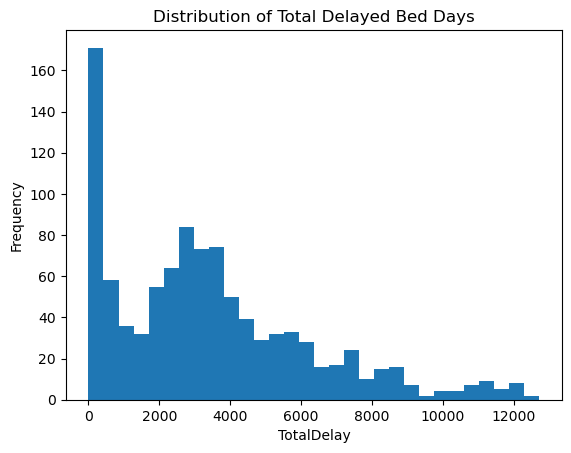

In [192]:
#Total Delayed Bed Days
plt.hist(df["totaldelayedbeddays"], bins=30)
plt.title("Distribution of Total Delayed Bed Days")
plt.xlabel("TotalDelay")
plt.ylabel("Frequency")
plt.show()

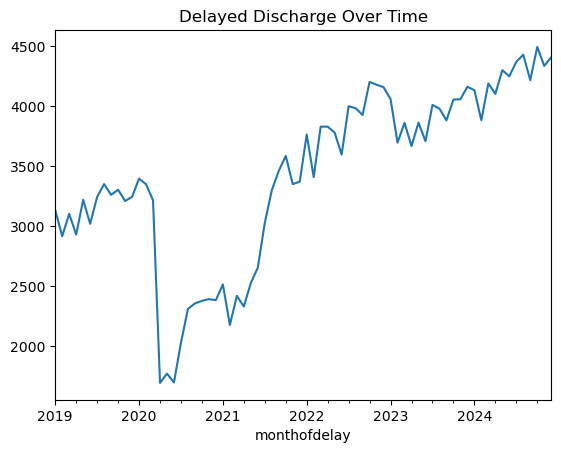

In [193]:
df.groupby("monthofdelay")["totaldelayedbeddays"].mean().plot()
plt.title("Delayed Discharge Over Time")
plt.show()

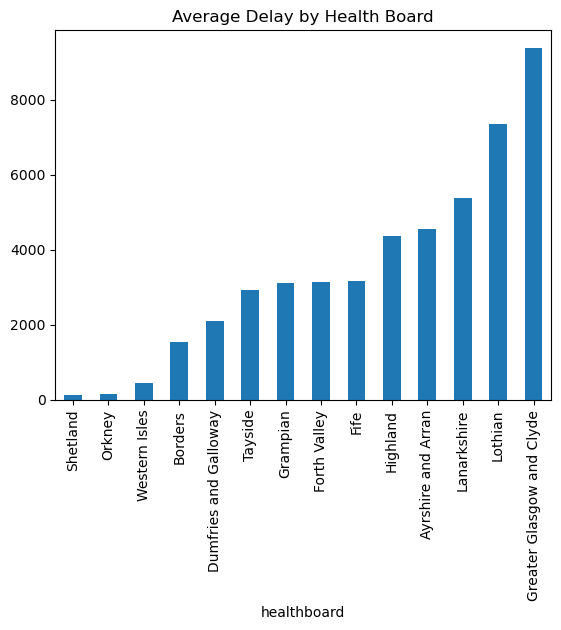

In [194]:
df.groupby("healthboard")["totaldelayedbeddays"].mean().sort_values().plot(kind="bar")
plt.title("Average Delay by Health Board")
plt.show()

In [195]:
df.corr(numeric_only=True)

,totaldelayedbeddays,prevmonthdelay,year,month,quarter,healthsocialrate,patientfamilyrate,awirate,nonawirate,pop18_74,pop75plus,elderlyrate,carehomeplaces,carehomecapacityrate
totaldelayedbeddays,1.000000,0.986657,0.189682,0.039431,0.040758,-0.154360,0.000510,0.328895,-0.122008,0.878085,0.894497,-0.606166,0.860941,0.463893
prevmonthdelay,0.986657,1.000000,0.186893,0.029057,0.029857,-0.159325,-0.000636,0.334592,-0.119925,0.878161,0.894185,-0.608258,0.859916,0.463562
year,0.189682,0.186893,1.000000,-0.002032,-0.001568,-0.029758,0.030236,0.133732,-0.111283,0.003748,0.061929,0.287015,-0.004001,-0.265092
month,0.039431,0.029057,-0.002032,1.000000,0.971670,0.046177,-0.017185,-0.041843,-0.018938,-0.002504,-0.002979,0.000015,-0.002637,-0.000637
quarter,0.040758,0.029857,-0.001568,0.971670,1.000000,0.044107,-0.011448,-0.043342,-0.016284,-0.001932,-0.002299,0.000011,-0.002035,-0.000492
healthsocialrate,-0.154360,-0.159325,-0.029758,0.046177,0.044107,1.000000,-0.226452,-0.702001,-0.602353,-0.177673,-0.216091,0.047209,-0.275359,-0.281304
patientfamilyrate,0.000510,-0.000636,0.030236,-0.017185,-0.011448,-0.226452,1.000000,0.051870,-0.167427,0.026684,-0.003754,0.023158,0.012415,-0.104447
awirate,0.328895,0.334592,0.133732,-0.041843,-0.043342,-0.702001,0.051870,1.000000,-0.058446,0.327278,0.356055,-0.183675,0.388444,0.284880
nonawirate,-0.122008,-0.119925,-0.111283,-0.018938,-0.016284,-0.602353,-0.167427,-0.058446,1.000000,-0.097714,-0.059419,0.113853,-0.015051,0.151977
pop18_74,0.878085,0.878161,0.003748,-0.002504,-0.001932,-0.177673,0.026684,0.327278,-0.097714,1.000000,0.983001,-0.804352,0.970827,0.580657


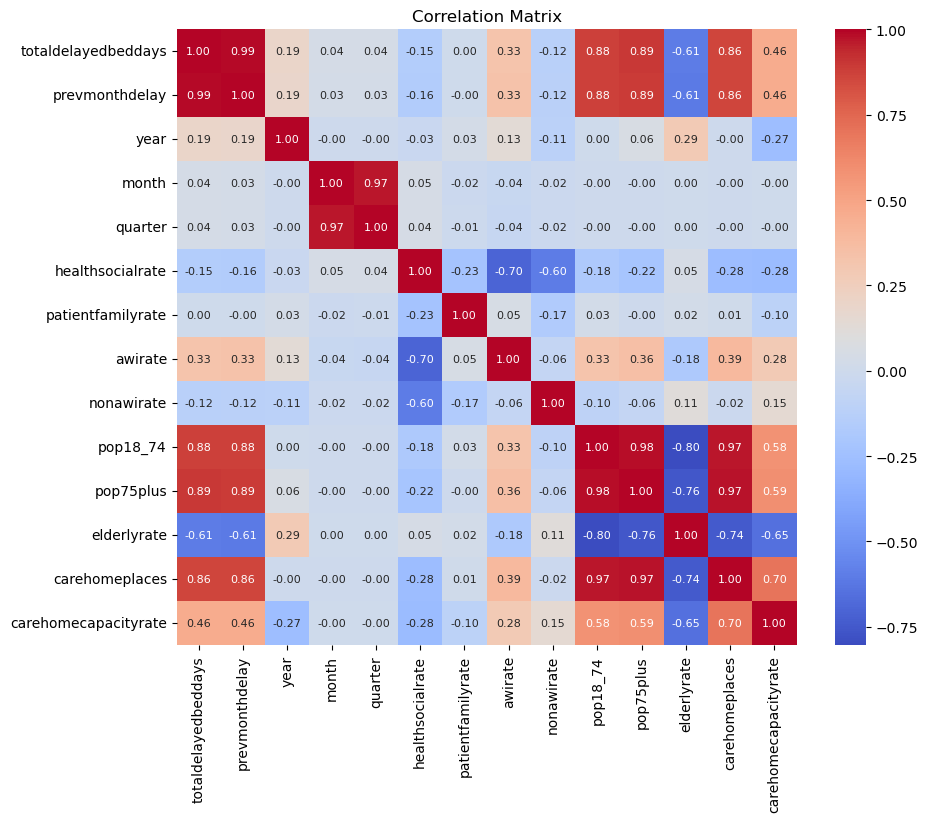

In [196]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt=".2f",
            annot_kws={"size":8},
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

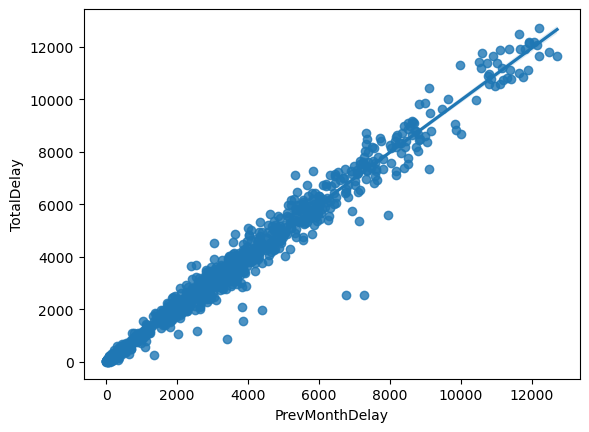

In [197]:
sns.regplot(x="prevmonthdelay", y="totaldelayedbeddays", data=df)
plt.xlabel("PrevMonthDelay")
plt.ylabel("TotalDelay")
plt.show()

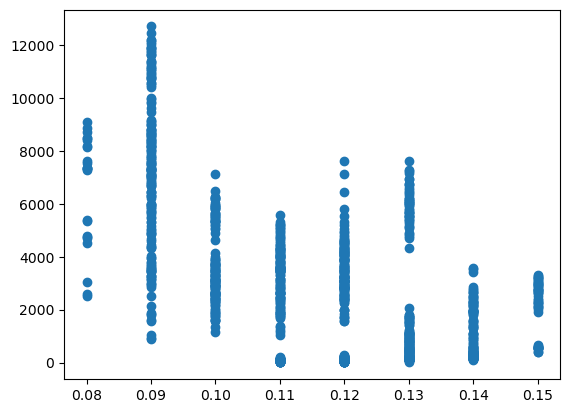

In [198]:
plt.scatter(df["elderlyrate"], df["totaldelayedbeddays"])

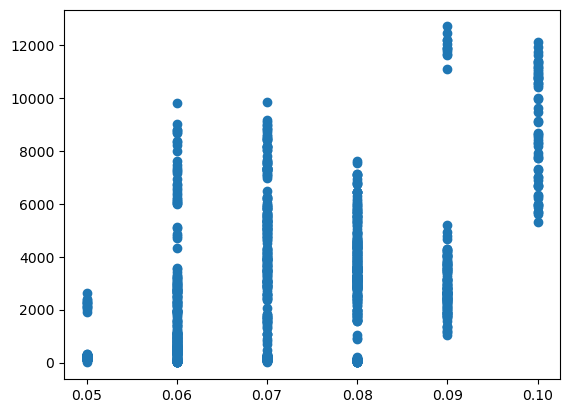

In [199]:
plt.scatter(df["carehomecapacityrate"], df["totaldelayedbeddays"])

{'whiskers': [<matplotlib.lines.Line2D at 0x12f115fd0>,
 'caps': [<matplotlib.lines.Line2D at 0x12f11ed80>,
 'boxes': [<matplotlib.lines.Line2D at 0x12f115d30>],
 'medians': [<matplotlib.lines.Line2D at 0x12f11e780>],
 'fliers': [<matplotlib.lines.Line2D at 0x12f11e480>],
 'means': []}

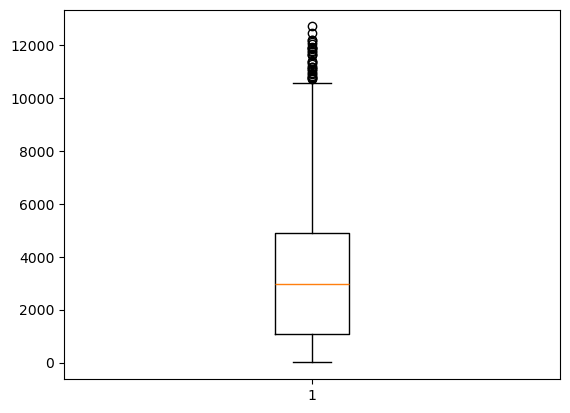

In [200]:
plt.boxplot(df["totaldelayedbeddays"])

## Machine Learning

### Importing Libraries

In [201]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Encoding Health Board

In [202]:
le = LabelEncoder()
df['hb_encoded'] = le.fit_transform(df['hbt'])

### Features(X) and Target(y)

In [203]:
features = [
    "prevmonthdelay",
    "healthsocialrate",
    "patientfamilyrate",
    "awirate",
    "nonawirate",
    "elderlyrate",
    "carehomecapacityrate",
    "carehomeplaces",
    "month",
    "year",
    "hb_encoded"
] 

In [204]:
X = df[features]
y = df["totaldelayedbeddays"]

### Train-test split

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

### Train Models

#### Linear Regression

In [206]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [207]:
y_pred_lr = lr.predict(X_test)

#### XG Boost

In [208]:
xgb = XGBRegressor(n_estimators=200, random_state=42)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [209]:
y_pred_xgb = xgb.predict(X_test)

#### Random Forest

In [210]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [211]:
y_pred_rf = rf.predict(X_test)

#### Gradient Boosting

In [212]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [213]:
y_pred_gb = gb.predict(X_test)

#### Evaluate Models

##### MAE, RMSE, R²

In [214]:
def evaluate(y_true, y_pred):
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²:", r2_score(y_true, y_pred))

In [215]:
print("Linear Regression")
evaluate(y_test, y_pred_lr)

print("XG Boost")
evaluate(y_test, y_pred_xgb)

print("Random Forest")
evaluate(y_test, y_pred_rf)

print("Gradient Boosting")
evaluate(y_test, y_pred_gb)

Linear Regression
MAE: 291.169155280744
RMSE: 500.94993660571544
R²: 0.9725172917131402
XG Boost
MAE: 307.08441162109375
RMSE: 518.2932627866197
R²: 0.9705814123153687
Random Forest
MAE: 307.2472139303483
RMSE: 545.2646083644398
R²: 0.96743991757664
Gradient Boosting
MAE: 286.5484383525709
RMSE: 495.91725509936094
R²: 0.9730667157126801


##### CV R² (5-fold)

In [216]:
lr_cv = cross_val_score(lr, X, y, cv=5, scoring='r2')
xgb_cv = cross_val_score(xgb, X, y, cv=5, scoring='r2')
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='r2')
gb_cv = cross_val_score(gb, X, y, cv=5, scoring='r2')

In [217]:
print("Linear Regression CV R²:", lr_cv)
print("Mean:", lr_cv.mean())

print("\nXG Boost CV R²:", xgb_cv)
print("Mean:", xgb_cv.mean())

print("\nRandom Forest CV R²:", rf_cv)
print("Mean:", rf_cv.mean())

print("\nGradient Boosting CV R²:", gb_cv)
print("Mean:", gb_cv.mean())

Linear Regression CV R²: [0.95623169 0.78268098 0.9783317  0.96150258 0.95883859]
Mean: 0.9275171052513616

XG Boost CV R²: [0.91811109 0.6748656  0.9434039  0.94681907 0.74382091]
Mean: 0.8454041123390198

Random Forest CV R²: [0.93389779 0.70818474 0.94777022 0.95638514 0.78703479]
Mean: 0.8666545337400763

Gradient Boosting CV R²: [0.9467484  0.79834409 0.96117463 0.96193069 0.48550649]
Mean: 0.8307408615877157


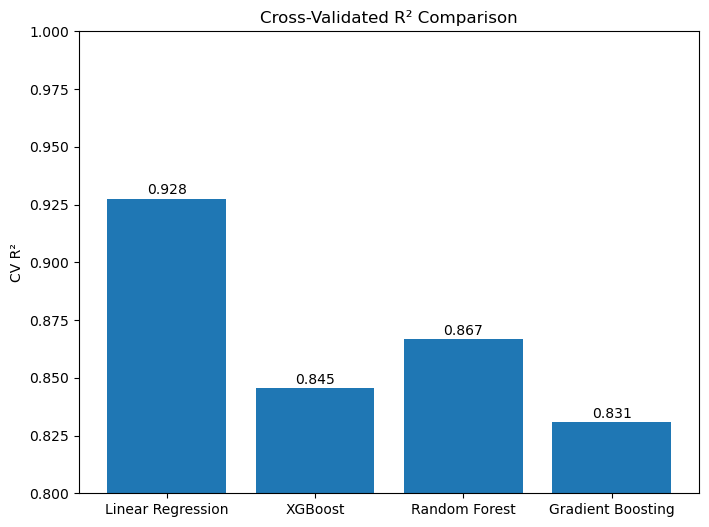

In [218]:
cv_means = {
    "Linear Regression": lr_cv.mean(),
    "XGBoost": xgb_cv.mean(),
    "Random Forest": rf_cv.mean(),
    "Gradient Boosting": gb_cv.mean()
}

models = list(cv_means.keys())
scores = list(cv_means.values())

plt.figure(figsize=(8,6))
plt.bar(models, scores)

for i, v in enumerate(scores):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.ylabel("CV R²")
plt.title("Cross-Validated R² Comparison")
plt.ylim(0.8, 1)

plt.show()

#### Feature Importance

<Axes: >

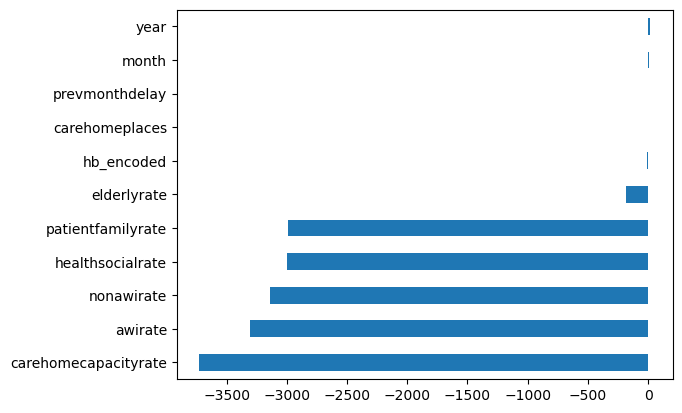

In [219]:
lr_coefficients = pd.Series(lr.coef_, index=X.columns)
lr_coefficients.sort_values().plot(kind="barh")

<Axes: >

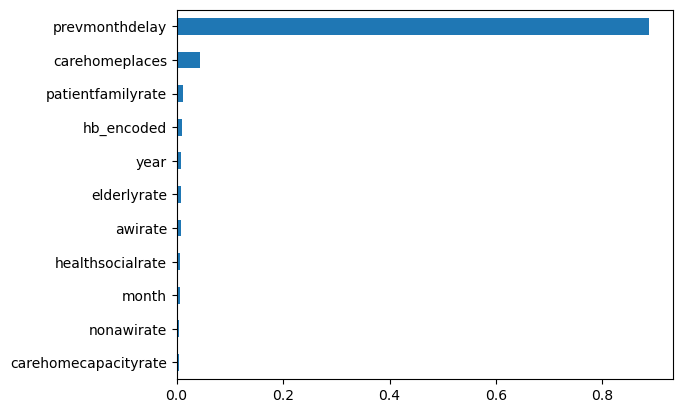

In [220]:
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns)
xgb_importance.sort_values().plot(kind="barh")

<Axes: >

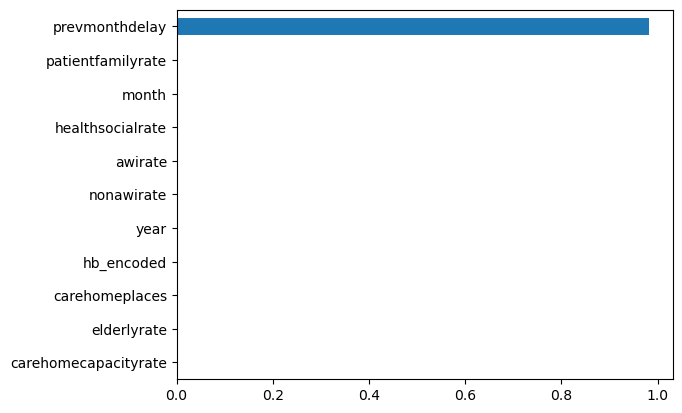

In [221]:
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_importance.sort_values().plot(kind="barh")

<Axes: >

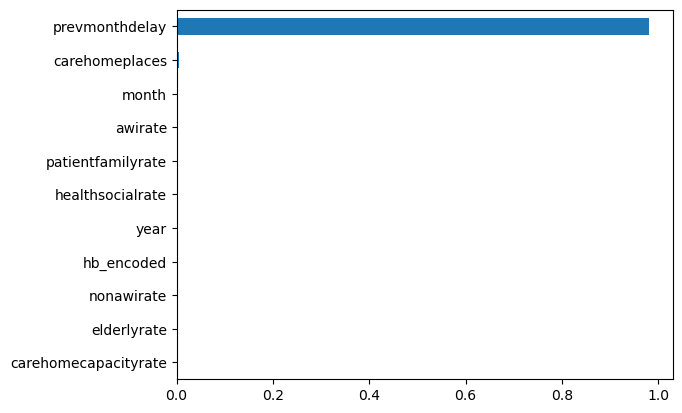

In [222]:
gb_importance = pd.Series(gb.feature_importances_, index=X.columns)
gb_importance.sort_values().plot(kind="barh")

#### Predictions

##### Linear Regression

In [223]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})
results.head()

,Actual,Predicted
930,11911,11754.307682
634,89,208.602731
686,410,356.180731
514,69,-79.760244
365,3902,4067.056325


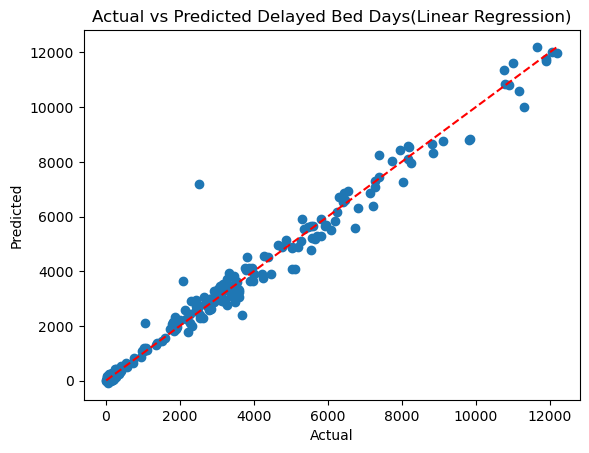

In [224]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Delayed Bed Days(Linear Regression)")
plt.show()

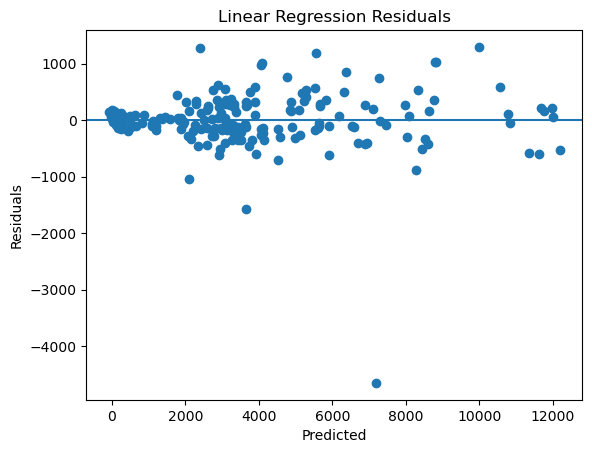

In [225]:
y_pred_lr = lr.predict(X_test)
residuals = y_test - y_pred_lr

plt.scatter(y_pred_lr, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Linear Regression Residuals")
plt.show()

##### XG Boost

In [226]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_xgb
})
results.head()

,Actual,Predicted
930,11911,12345.602539
634,89,77.118462
686,410,535.457520
514,69,3.509047
365,3902,4028.122314


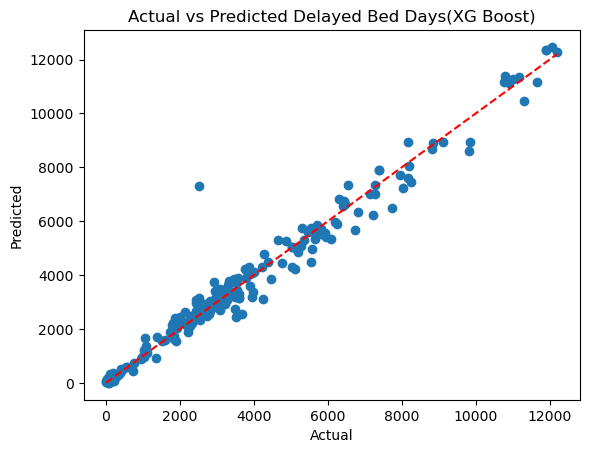

In [227]:
plt.scatter(y_test, y_pred_xgb)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Delayed Bed Days(XG Boost)")
plt.show()

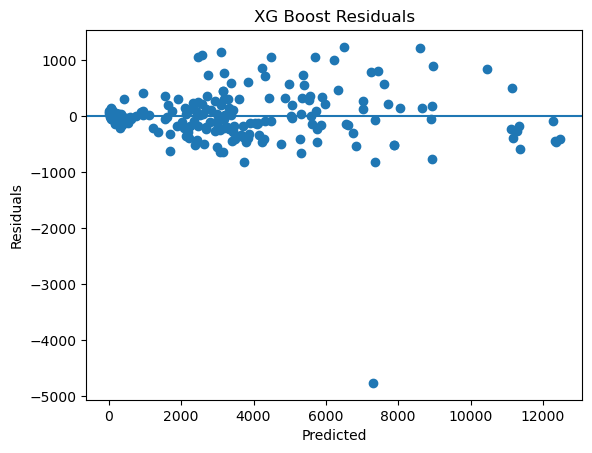

In [228]:
y_pred_xgb = xgb.predict(X_test)
residuals = y_test - y_pred_xgb

plt.scatter(y_pred_xgb, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("XG Boost Residuals")
plt.show()

##### Random Forest

In [229]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})
results.head()

,Actual,Predicted
930,11911,11988.28
634,89,132.38
686,410,408.51
514,69,56.70
365,3902,4242.22


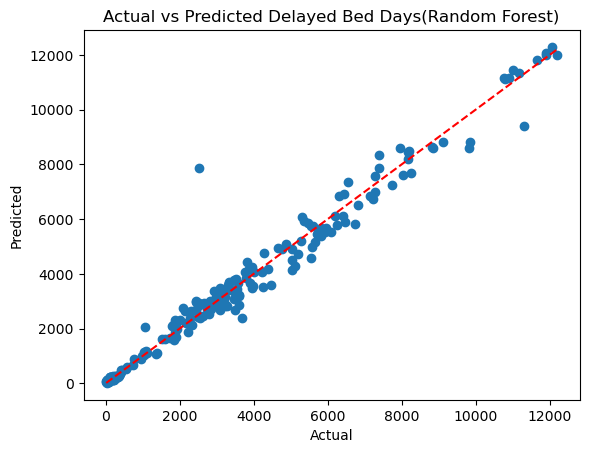

In [230]:
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Delayed Bed Days(Random Forest)")
plt.show()

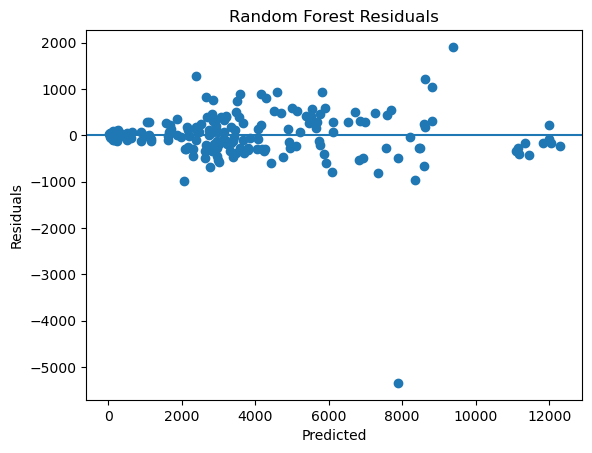

In [231]:
y_pred_rf = rf.predict(X_test)
residuals = y_test - y_pred_rf

plt.scatter(y_pred_rf, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Random Forest Residuals")
plt.show()

##### Gradient Boosting

In [232]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_gb
})
results.head()

,Actual,Predicted
930,11911,12032.814722
634,89,100.471557
686,410,685.513300
514,69,-43.850517
365,3902,4258.720108


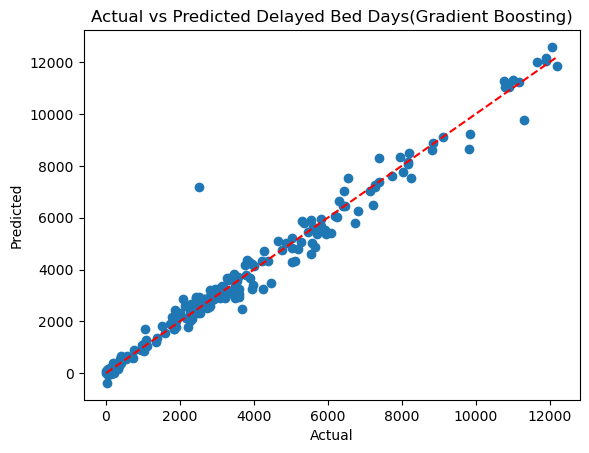

In [233]:
plt.scatter(y_test, y_pred_gb)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Delayed Bed Days(Gradient Boosting)")
plt.show()

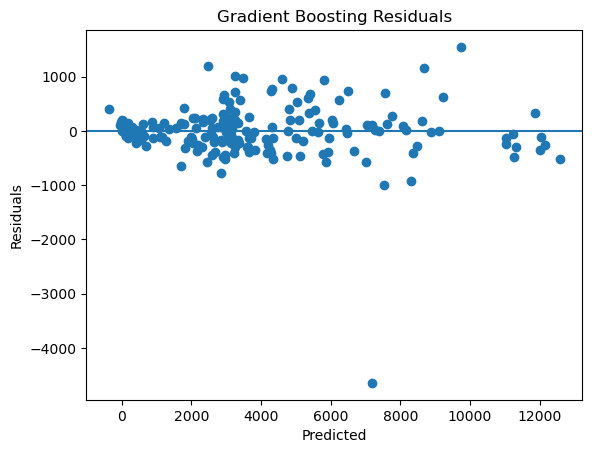

In [234]:
y_pred_gb = gb.predict(X_test)
residuals = y_test - y_pred_gb

plt.scatter(y_pred_gb, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Gradient Boosting Residuals")
plt.show()

#### SHAP

In [235]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.7/565.7 kB 4.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 8.4 MB/s  0:00:02m0:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]
      Successfully uninstalled numpy-1.26.4━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


##### Import Libraries

In [237]:
import shap

##### Create SHAP explainer

In [239]:
explainer = shap.TreeExplainer(gb)

##### Calculate SHAP values

In [240]:
shap_values = explainer.shap_values(X)

##### Plot SHAP summary

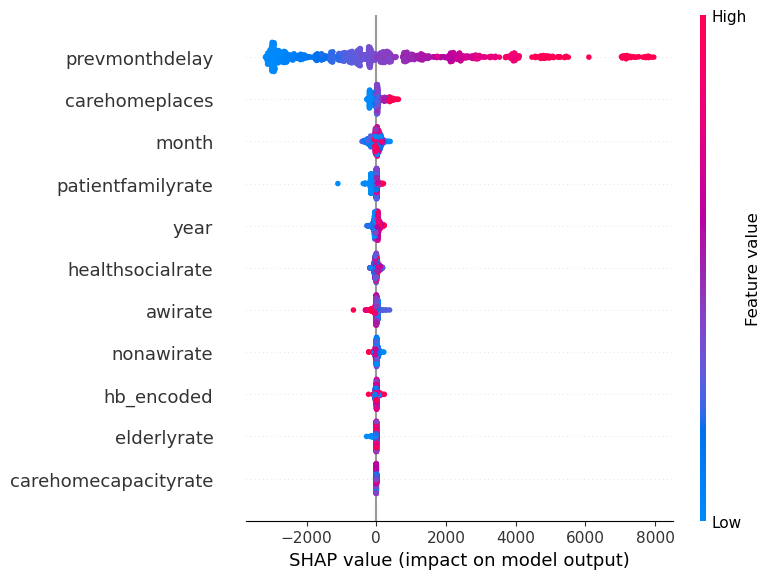

In [241]:
shap.summary_plot(shap_values, X)

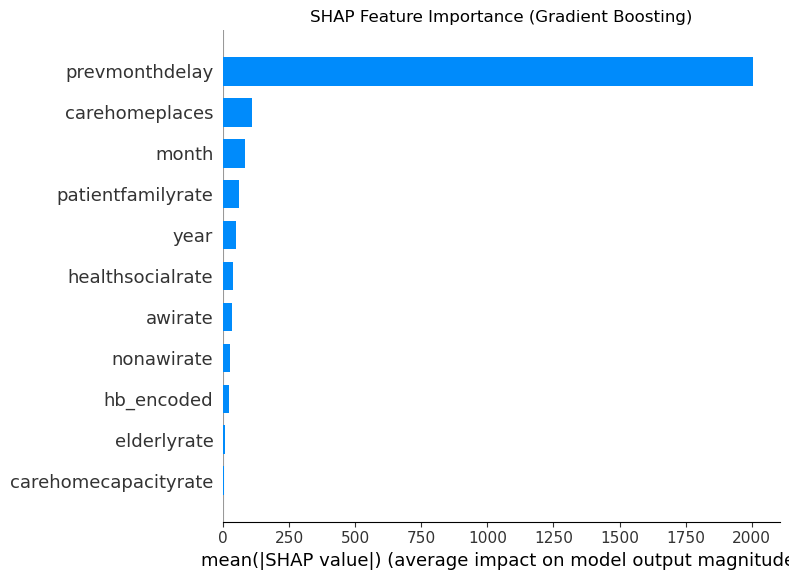

In [245]:
# Bar Chart(Feature Importance)
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Gradient Boosting)")
plt.tight_layout()
plt.show()

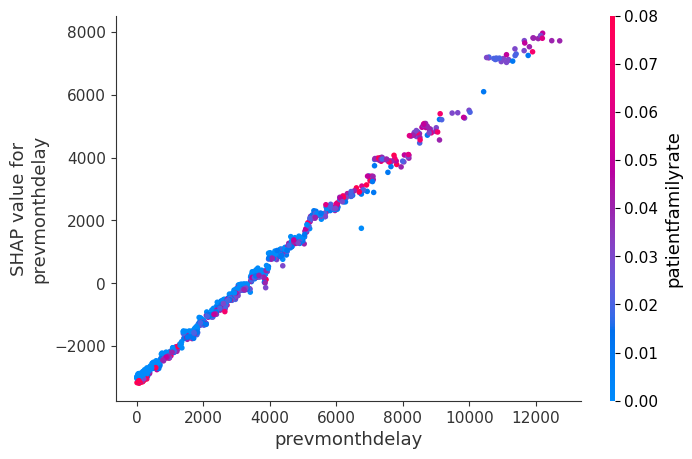

In [243]:
# Dependence plot
shap.dependence_plot("prevmonthdelay", shap_values, X)